#                        Summer Internship 2021 (Major Project)

 * **By**: Chowdhury Swayansu Satyaprjna
 * **Sem**: 4th 
 * **Branch** : CSE
 * Silicon Institute of Technology(SIT West)

## Topic: Heart Attack Analysis & Prediction ( with data set "heart.csv" from Kaggle)

### Part A : Data Pre-Processing

#### Importing The required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# plt.style.use('dark_background')
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split

#### Importing the dataset

In [2]:
ds = pd.read_csv("heart.csv")
ds

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


**Description of the data set**:

The data set consisists of several features with their different values of the surveyed cardiac patients.

In [3]:
print("Total no. of columns and rows present in the data set are: ", (ds.shape))

Total no. of columns and rows present in the data set are:  (303, 14)


In [4]:
# Sum of the null values(if any)
ds.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [5]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


#### Visualizing and interpreting the data


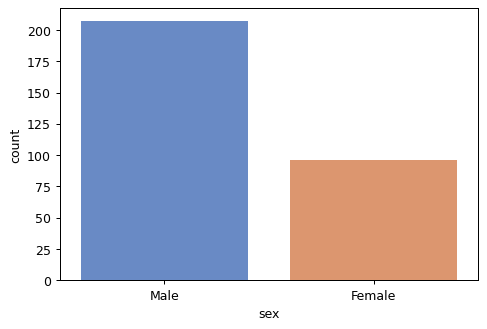

In [6]:
plt.figure(dpi = 90)
sex_data = ds.sex.map({1: 'Male', 0: 'Female'})
sns.countplot(x=sex_data, palette = 'muted', alpha = 0.9)
plt.show()

The Above plot shows the number of the males and females in the data set. From the plotted data it is been obvious that there are 200 males and 80 females approx.

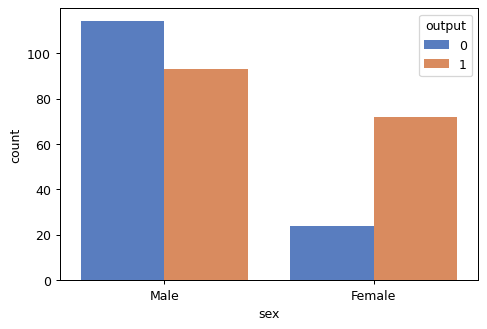

In [7]:
# The no of males and females based on the target concerned that is being affected by the heart attack or not
plt.figure(dpi = 90)
sex_data_target = ds.sex.map({1: 'Male', 0: 'Female'})
sns.countplot(x = sex_data_target, hue = ds.output, palette = 'muted')
plt.show()

The Above plot shows The no. of male and female affected by thye heart disease.

In [8]:
# Checking for the duplicate values
ds.duplicated().sum()

1

**From the above cells:** 
* it has been clear that the data set has no **null** Values and 1 Duplicate value.



In [9]:
# Dropping The Duplicate row and unnecessery columns


ds.drop_duplicates(inplace=True)
ds.shape

(302, 14)

In [ ]:
# Dropping unnecessery columns
ds.drop(columns=['slp', 'caa','thall'])

The Duplicate Data has been Dropped with 302 Rows remaining and 11 attributes.

#### Partitioning the data set into FM and DVV

In [10]:
f  = ds.iloc[:,:-1].values
l = ds.iloc[:,-1].values

In [11]:
f[:6,:]

array([[ 63. ,   1. ,   3. , 145. , 233. ,   1. ,   0. , 150. ,   0. ,
          2.3,   0. ,   0. ,   1. ],
       [ 37. ,   1. ,   2. , 130. , 250. ,   0. ,   1. , 187. ,   0. ,
          3.5,   0. ,   0. ,   2. ],
       [ 41. ,   0. ,   1. , 130. , 204. ,   0. ,   0. , 172. ,   0. ,
          1.4,   2. ,   0. ,   2. ],
       [ 56. ,   1. ,   1. , 120. , 236. ,   0. ,   1. , 178. ,   0. ,
          0.8,   2. ,   0. ,   2. ],
       [ 57. ,   0. ,   0. , 120. , 354. ,   0. ,   1. , 163. ,   1. ,
          0.6,   2. ,   0. ,   2. ],
       [ 57. ,   1. ,   0. , 140. , 192. ,   0. ,   1. , 148. ,   0. ,
          0.4,   1. ,   0. ,   1. ]])

In [12]:
l

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

#### Replacing The missing Values

The data set do not contain any of the missing values so the step can be skipped.

#### Splitting The data into train and test Split

In [13]:
f_train, f_test, l_train, l_test = train_test_split(f,l, test_size=0.2, random_state=42)

In [14]:
f_test

array([[5.50e+01, 1.00e+00, 0.00e+00, 1.32e+02, 3.53e+02, 0.00e+00,
        1.00e+00, 1.32e+02, 1.00e+00, 1.20e+00, 1.00e+00, 1.00e+00,
        3.00e+00],
       [6.40e+01, 1.00e+00, 2.00e+00, 1.25e+02, 3.09e+02, 0.00e+00,
        1.00e+00, 1.31e+02, 1.00e+00, 1.80e+00, 1.00e+00, 0.00e+00,
        3.00e+00],
       [5.70e+01, 1.00e+00, 2.00e+00, 1.50e+02, 1.26e+02, 1.00e+00,
        1.00e+00, 1.73e+02, 0.00e+00, 2.00e-01, 2.00e+00, 1.00e+00,
        3.00e+00],
       [6.60e+01, 1.00e+00, 1.00e+00, 1.60e+02, 2.46e+02, 0.00e+00,
        1.00e+00, 1.20e+02, 1.00e+00, 0.00e+00, 1.00e+00, 3.00e+00,
        1.00e+00],
       [7.10e+01, 0.00e+00, 2.00e+00, 1.10e+02, 2.65e+02, 1.00e+00,
        0.00e+00, 1.30e+02, 0.00e+00, 0.00e+00, 2.00e+00, 1.00e+00,
        2.00e+00],
       [5.70e+01, 1.00e+00, 2.00e+00, 1.50e+02, 1.68e+02, 0.00e+00,
        1.00e+00, 1.74e+02, 0.00e+00, 1.60e+00, 2.00e+00, 0.00e+00,
        2.00e+00],
       [4.60e+01, 0.00e+00, 0.00e+00, 1.38e+02, 2.43e+02, 0.00e+00,
  

In [15]:
f_train

array([[42.,  1.,  1., ...,  2.,  0.,  2.],
       [68.,  1.,  2., ...,  1.,  0.,  3.],
       [67.,  1.,  0., ...,  1.,  2.,  3.],
       ...,
       [69.,  1.,  3., ...,  1.,  1.,  2.],
       [61.,  1.,  3., ...,  1.,  2.,  2.],
       [63.,  0.,  1., ...,  2.,  2.,  2.]])

#### Feature scaling 


In [16]:
sc = StandardScaler()
f_train = sc.fit_transform(f_train)
f_test = sc.fit_transform(f_test)

In [17]:
f_train[:6,:]

array([[-1.350641  ,  0.73145871,  0.        , -0.63071093,  0.92713761,
        -0.39129279,  0.89002765,  0.54913872, -0.6591842 , -0.89583663,
         0.96543644, -0.68348955, -0.54576155],
       [ 1.48742624,  0.73145871,  0.9664929 ,  2.75336332,  0.5269804 ,
         2.55563104, -0.99152203,  0.01207102,  1.51702665,  0.54347422,
        -0.68470669, -0.68348955,  1.14050171],
       [ 1.37826981,  0.73145871, -0.9664929 , -0.34870475,  0.1458783 ,
         2.55563104,  0.89002765,  0.59389436, -0.6591842 , -0.71592277,
        -0.68470669,  1.35010281,  1.14050171],
       [ 0.06839262, -1.36713116,  0.        ,  0.21530763,  0.06965787,
        -0.39129279, -0.99152203,  0.50438308, -0.6591842 ,  0.36356037,
        -0.68470669, -0.68348955, -0.54576155],
       [ 1.05080051,  0.73145871,  0.9664929 ,  0.49731382,  1.68934182,
        -0.39129279,  0.89002765,  0.37011616, -0.6591842 , -0.89583663,
         0.96543644, -0.68348955, -0.54576155],
       [ 0.28670548, -1.367131

## Part  B:Buiulding The training Model

### 1. Logistic regression Model

In [18]:
# Importing thr rewuired libraries
from sklearn.linear_model import LogisticRegression

In [19]:
# Traing The Model
lgc = LogisticRegression(random_state=0)
lgc.fit(f_train, l_train)

LogisticRegression(random_state=0)

In [20]:
l_estimated = lgc.predict(f_test)
l_estimated

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1], dtype=int64)

In [21]:
# Concatenating the predicted value with the actual values
np.concatenate((l_estimated.reshape(len(l_estimated),1),l_test.reshape(len(l_test),1)),1)

array([[0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [1, 0],
       [0, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [1, 0]], dtype=int64)

this above snippet of the code shows how the values are varying from the actual data output from the data we prediccted through the Model. 


In [22]:
# Preformnace Metrics
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report

In [23]:
# Confusion Matrix
cf = confusion_matrix(l_test,l_estimated)
cf

array([[24,  5],
       [ 3, 29]], dtype=int64)

* The above matrix shows that the data belonging to the first catagory(class 0) is **29**.
* The data belonging to the second catagory (class 1) is **32**.
* The no. of misfired data from the class 0 to class 1: **5**.
* The no. of data misfired to class 0 from Class 1 is: **3**

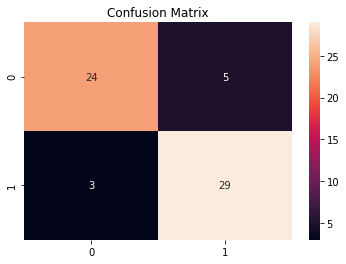

In [24]:
# Visulaization Of the confusion Matrix
import seaborn as sns
plt.xlabel('predicted labels')
plt.ylabel('Actual label')
plt.title("Confusion Matrix")
sns.heatmap(cf, annot=True);

In [25]:
accuracy_score(l_test,l_estimated)

0.8688524590163934

The Accuracy of the model is 86.8%.

In [26]:
precision_score(l_test, l_estimated)

0.8529411764705882

In [27]:
# Classification report of Testing data and the predicted data
print(classification_report(l_estimated, l_test))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        27
           1       0.91      0.85      0.88        34

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



1. The precision of the model is **85.2%**

### 2. KNN Algorithm

Let's assume the n = 5 for the first case.

In [28]:
# Importing the libraries 
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, weights = 'uniform',p = 2)
knn.fit(f_train,l_train)

KNeighborsClassifier()

In [29]:
# Prediction of the data using the Model
y_estknn = knn.predict(f_test)
y_estknn

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1], dtype=int64)

The Performance matrix using the n = 5 is as follows:

In [30]:
# Confusion Matrix
cfknn = confusion_matrix(l_test,y_estknn)
cfknn

array([[26,  3],
       [ 4, 28]], dtype=int64)

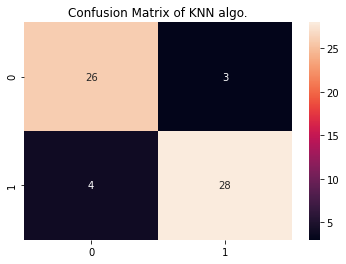

In [31]:
# Visulaization Of the confusion Matrix
import seaborn as sns
plt.xlabel('predicted labels')
plt.ylabel('Actual label')
plt.title("Confusion Matrix of KNN algo.")
sns.heatmap(cfknn, annot=True);

In [32]:
print("the accuracy score of KNN using n = 5 is: ",accuracy_score(l_test,y_estknn)*100)
print("the precision score of KNN using n = 5 is: ",precision_score(l_test,y_estknn)*100)

the accuracy score of KNN using n = 5 is:  88.52459016393442
the precision score of KNN using n = 5 is:  90.32258064516128


**Elbow method**

In [33]:
error_rate = []
for i in range(1,30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(f_train,l_train)
    predi = knn.predict(f_test)
    error_rate.append(np.mean(predi != l_test))

Text(0.5, 1.0, 'K vs. error_rate')

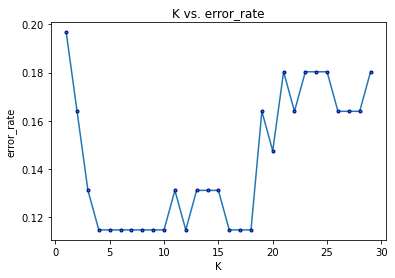

In [34]:
plt.plot(range(1,30),error_rate,marker = '.',markeredgecolor='darkblue')
plt.xlabel('K')
plt.ylabel('error_rate')
plt.title('K vs. error_rate')

Using elbow method It is obvious that the error is minimum in the range of 5-10. So taking **n=10**:

In [35]:
knn = KNeighborsClassifier(n_neighbors=10, weights = 'uniform',p = 2)
knn.fit(f_train,l_train)

KNeighborsClassifier(n_neighbors=10)

In [36]:
# Prediction of the data using the Model
y_estknn1 = knn.predict(f_test)
y_estknn1

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1], dtype=int64)

In [37]:
# Confusion Matrix
cfknn2 = confusion_matrix(l_test,y_estknn1)
cfknn2

array([[26,  3],
       [ 4, 28]], dtype=int64)

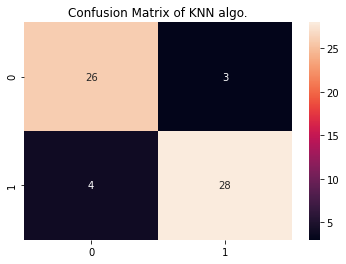

In [38]:
# Visulaization Of the confusion Matrix
import seaborn as sns
plt.xlabel('predicted labels')
plt.ylabel('Actual label')
plt.title("Confusion Matrix of KNN algo.")
sns.heatmap(cfknn2, annot=True);

In [39]:
print("the accuracy score of KNN using n = 5 is: ",accuracy_score(l_test,y_estknn1)*100)
print("the precision score of KNN using n = 5 is: ",precision_score(l_test,y_estknn1)*100)

the accuracy score of KNN using n = 5 is:  88.52459016393442
the precision score of KNN using n = 5 is:  90.32258064516128


There is no change in the Confiusion matrix as well as the Scores so, The value of the n can be taken between any value between 5 -10(Inclusive)